<a href="https://colab.research.google.com/github/dpreese/CS453-Projects/blob/master/Assignments/Stat_220_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drbob-richardson/stat220/blob/main/Assignments/Stat_220_HW1.ipynb)


**Problem 1**. Give an example of a variable that is (a) categorical; (b) quantitative; (c) discrete; (d) continuous.



**Problem 2**. Analyze the Carbon_West data file using the following code.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
carbon_west = pd.read_fwf("https://stat4ds.rwth-aachen.de/data/Carbon_West.dat")


Part a. Construct a histogram of CO2 emissions.

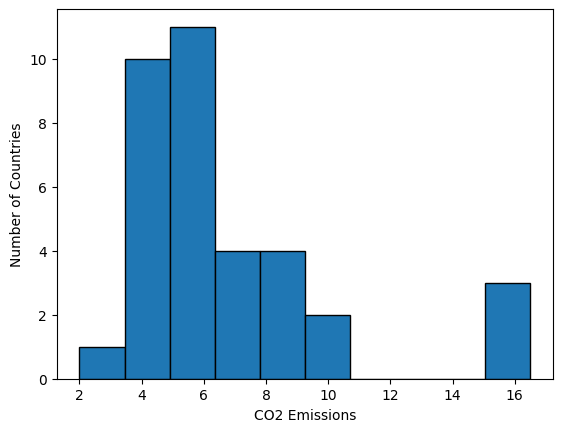

In [7]:
# print(carbon_west)
plt.hist(carbon_west.CO2, bins=10, edgecolor="black")
plt.xlabel("CO2 Emissions")
plt.ylabel("Number of Countries")
plt.show()

Part b. Find the mean, median, and standard deviation.

In [9]:
mean = carbon_west.CO2.mean()
median = carbon_west.CO2.median()
standard_deviation = carbon_west.CO2.std()
print(mean,median, standard_deviation)

6.717142857142858 5.9 3.3569493954627134


**Problem 3**. Read in the murder data set using the following code. The variable murder is the murder rate (per 100,000 population) for each state in the U.S. in 2017 according to the FBI Uniform Crime Reports. At first, do not use the observation for D.C. (DC).

In [10]:
murders = pd.read_fwf("https://stat4ds.rwth-aachen.de/data/Murder.dat")

Part a. Find the mean and standard deviation for murders without D.C.

In [16]:
new_murders = murders[:-1]
murder_mean = new_murders.murder.mean()
murder_median = new_murders.murder.median()
murder_standard_deviation = new_murders.murder.std()
print(murder_mean, murder_median, murder_standard_deviation)

4.874 4.85 2.586291174793806


Part b. Find the five-number  summary without D.C.

In [19]:
murder_min_val = new_murders.murder.min()
murder_q1 = new_murders.murder.quantile(0.25)
murder_median = new_murders.murder.median()
murder_q3 = new_murders.murder.quantile(0.75)
murder_max_val = new_murders.murder.max()
print(murder_min_val, murder_q1, murder_median, murder_q3, murder_max_val)
print(new_murders.murder.mean())

1.0 2.625 4.85 6.175 12.4
4.874


Part c. Now include the observation for D.C. and recalculate the mean, median, and five-number summary. What is affected more by this outlier: The mean or the median? The range or the inter-quartile range?

In [20]:
murder_min_val = murders.murder.min()
murder_q1 = murders.murder.quantile(0.25)
murder_median = murders.murder.median()
murder_q3 = murders.murder.quantile(0.75)
murder_max_val = murders.murder.max()
print(murder_min_val, murder_q1, murder_median, murder_q3, murder_max_val)
print(murders.murder.mean())
print("The range gets affected the most when adding DC into the stats along with the mean")

1.0 2.6500000000000004 5.0 6.45 24.2
5.252941176470588
The range gets affected the most when adding DC into the stats


**Problem 4**. Read in the Houses data file using the following code.  The variables include price (thousands of dollars), size (square feet), tax bill (dollars), number of bathrooms, number of bedrooms, and whether the house is new (1 = yes, 0 = no) for 100 home sales in Gainesville, Florida. Let
y = selling price and x = size of home.

In [25]:
houses = pd.read_fwf("https://stat4ds.rwth-aachen.de/data/Houses.dat")
print(houses)

    case   price  size  new  taxes  bedrooms  baths
0      1  419.85  2048    0   3104         4      2
1      2  219.75   912    0   1173         2      1
2      3  356.55  1654    0   3076         4      2
3      4  300.00  2068    0   1608         3      2
4      5  239.85  1477    0   1454         3      3
..   ...     ...   ...  ...    ...       ...    ...
95    96  264.00  1060    0    990         2      2
96    97  294.75  1730    0   3030         3      2
97    98  198.30  1370    0   1580         3      2
98    99  132.60  1560    0   1770         3      2
99    10  190.80  1340    0   1430         3      2

[100 rows x 7 columns]


Part a. Construct a scatterplot between square feet and price of a home.

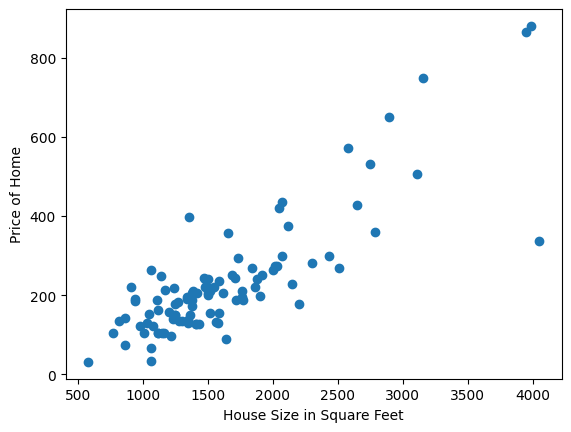

In [34]:
x_data = houses["size"]
# print(x_data)
plt.xlabel("House Size in Square Feet")
y_data = houses.price
# print(y_data)
plt.ylabel("Price of Home")
plt.scatter(x_data, y_data)

Part b. Find the correlation between the two variables.

In [36]:
import numpy as np
correlation_matrix = np.corrcoef(x_data, y_data)
pearson_correlation = correlation_matrix[0, 1]
print(pearson_correlation)


0.8337847885586537


Part c. Find and plot the regression line on top of the scatterplot.

Text(0.5, 1.0, 'Scatterplot with Linear Regression')

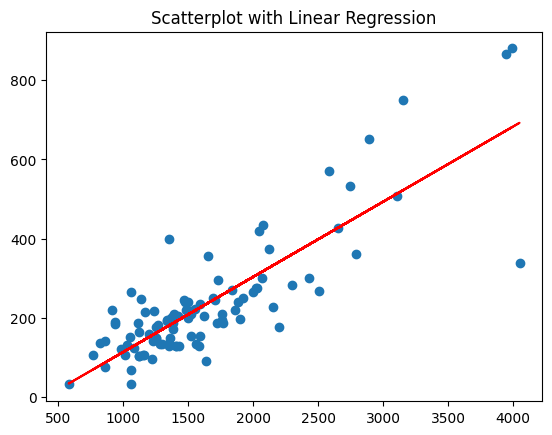

In [38]:
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
regression_line = slope * x_data + intercept
plt.scatter(x_data, y_data)
plt.plot(x_data, regression_line, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Scatterplot with Linear Regression')

Part d. Create a side by side boxplot of price comparing homes that are new and homes that are not new.

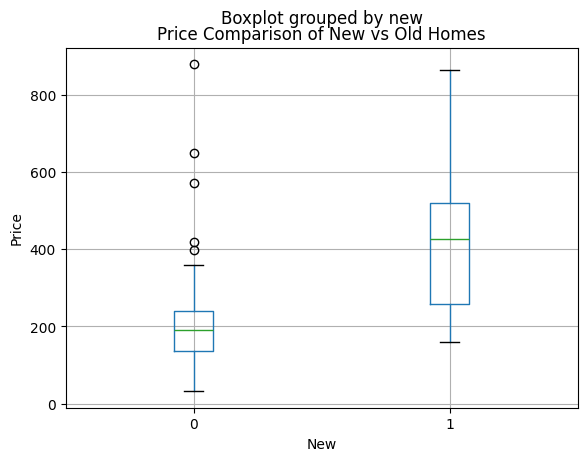

In [47]:
houses.boxplot(column="price", by="new")
plt.xlabel("New")
plt.ylabel("Price")
plt.title("Price Comparison of New vs Old Homes")
plt.show()



Part e. What is the relationship between size and price.  Justify your answer using the plots created. Do the same for the relationship between price and whether or not a house is new, again using the plot to justify your answer.

The scatterplot of house size versus price shows a clear positive relationship showing that larger homes generally cost more. As square footage increases, prices tend to rise with an especially sharp increases for houses above about 2,000 square feet. In contrast the boxplot comparing new and old homes shows that new homes are typically much more expensive than old ones. The median price and overall price range for new homes are noticeably higher, and new homes also display more high-price outliers.

**Problem 5**. Using the Happy data file read in by the following code. Construct the contingency table relating marital status and happiness.

In [49]:
happy = pd.read_csv("https://stat4ds.rwth-aachen.de/data/Happy.dat",sep=r'\s+')
print(happy)

      subject  happiness  marital  gender
0           1          1        1    male
1           2          1        1    male
2           3          1        1    male
3           4          1        1    male
4           5          1        1    male
...       ...        ...      ...     ...
2137     2138          3        3  female
2138     2139          3        3  female
2139     2140          3        3  female
2140     2141          3        3  female
2141     2142          3        3  female

[2142 rows x 4 columns]


In [50]:
df = pd.DataFrame(happy)
contingency_table = pd.crosstab(df['marital'], df['happiness'])
print(contingency_table)

happiness    1    2    3
marital                 
1          432  504   61
2           92  282  103
3          124  409  135
